# Antenna Tilt Optimization — 1a: single-antenna geometry and the RF field

Builds the single-sector RF model step by step, making each assumption explicit and verifying every
quantity against the Ericsson LTE model (Athley & Johansson, 2010; `docs/references/`). The physics
lives in `telecomopt.rf`; this notebook derives, checks, and visualizes it.

Sections: **(1) geometry** — the direction from antenna to a ground point · (2) path loss ·
(3) elevation gain and tilt · (4) path gain → SNR → spectral efficiency · (5) coverage vs tilt.


## Scope and assumptions of this first model

- **Flat ground**, with antenna and receiver heights measured from the same ground level.
- A **fixed antenna** and a **fixed observation point** 1.5 m above the ground (a "location"; user traffic
  and spatial distributions are introduced later, in 1b).
- `d > 0` is the **horizontal** distance, not the slant antenna–point distance.
- We take a **vertical cross-section along the sector's boresight** (forward direction). Azimuth is
  deferred to the full-sector extension.
- This section is **geometry (direction) only** — it makes no assumption about whether the path is
  obstructed. The path-loss and antenna-pattern expressions added next are **empirical models**, not
  first-principles derivations; the aim is to build the model step by step with its assumptions
  stated.


## 1. Geometry — the depression angle to a ground point

A ground point at horizontal distance $d$ from the tower is seen by the antenna at an angle **below
the horizon**:

$$\beta(d) = \arctan\!\left(\frac{h_{\mathrm{BS}} - h_{\mathrm{UE}}}{d}\right),
\qquad \Delta h = h_{\mathrm{BS}} - h_{\mathrm{UE}} = 30 - 1.5 = 28.5\ \text{m}.$$

**Convention.** $\beta$ is measured **positive downward** (horizon $\to$ ground). Ericsson defines
elevation **positive upward**, so with zero mechanical tilt $\alpha_{\text{Ericsson}} = -\beta$. The
beam is steered by a downtilt $t$ (also positive downward); in this vertical slice the antenna aims
at the ground point whose $\beta$ equals $t$. The library encodes this consistently — its elevation
gain uses $(\beta - t)$ and peaks at $\beta = t$ — so no sign ambiguity propagates into the model.

**Intuition.** A point *close* to the tower has a *large* $\beta$ (steep, looking down); a *far*
point has $\beta \to 0$ (near the horizon). Because the beam has finite width (elevation HPBW
$6.5°$), points within a few degrees of the pointing angle also receive strong gain — an exact match
is the *peak* direction, not the only strong one. In short: **geometry fixes the direction to a
point; tilt fixes where the beam points.**

**Numerical note.** As $d \to 0$ the point is under the mast ($\beta \to 90°$); `elevation_angle_deg`
clamps $d \ge 1$ m to avoid a division by zero.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
# The single-antenna RF chain already lives (and is tested) in telecomopt.rf — we import and call it.
from telecomopt.rf import RFParams, elevation_angle_deg, path_loss_db, to_linear, to_db

p = RFParams()
delta_h = p.bs_height - p.ue_height          # 28.5 m
print(f"h_BS = {p.bs_height} m,  h_UE = {p.ue_height} m,  delta_h = {delta_h} m")


h_BS = 30.0 m,  h_UE = 1.5 m,  delta_h = 28.5 m


In [10]:
# beta(d): the downward angle to a ground point. elevation_angle_deg takes a SCALAR distance (m).
print(f"{'d [m]':>7}{'beta [deg]':>12}")
for d0 in (50, 200, 500, 1000):
    print(f"{d0:7d}{elevation_angle_deg(d0):12.2f}")


  d [m]  beta [deg]
     50       29.68
    200        8.11
    500        3.26
   1000        1.63


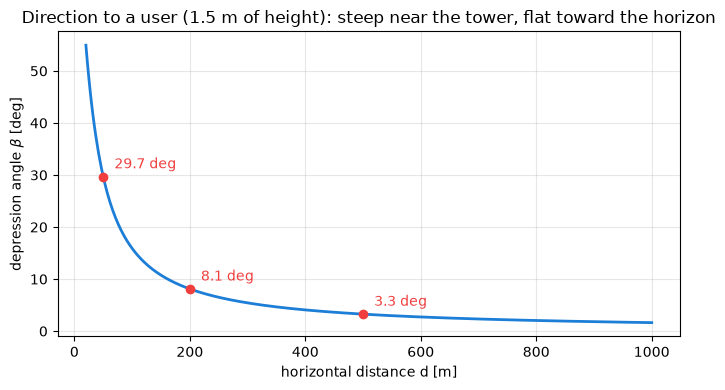

In [11]:
d = np.linspace(20, 1000, 400)
beta = np.array([elevation_angle_deg(x) for x in d]) 

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(d, beta, color="#1c7ed6", lw=2)
for d0 in (50, 200, 500):
    ax.plot(d0, elevation_angle_deg(d0), "o", color="#f03e3e")
    ax.annotate(f"{elevation_angle_deg(d0):.1f} deg", (d0, elevation_angle_deg(d0)),
                textcoords="offset points", xytext=(8, 6), color="#f03e3e")
ax.set_xlabel("horizontal distance d [m]")
ax.set_ylabel(r"depression angle $\beta$ [deg]")
ax.set_title("Direction to a user (1.5 m of height): steep near the tower, flat toward the horizon")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**Reading the curve.** $\beta$ falls off quickly at first and then flattens: for large $d$,
$\arctan(\Delta h / d) \approx \Delta h / d \to 0\ \text{(radians)}$, so beyond a few hundred metres every point sits
within a narrow band close to the horizon. That is why a single fixed downtilt can serve a wide
range of far distances but is very selective about near ones — the geometry we will feed into the
elevation pattern next.


## 2. Path loss — why received power decreases with distance

Even in free space, an isotropic source spreads its power over a sphere of area $4\pi R^2$, so power
density falls as $1/R^2$ (path-loss exponent 2). Real environments add reflection, diffraction and
obstruction; an empirical model summarizes their net effect at a chosen fidelity.

Two contributions stay conceptually separate:

| Contribution | Question it answers |
|---|---|
| **Antenna gain** | How strongly does the antenna radiate toward this direction? |
| **Path loss** | How much does propagation attenuate the signal between the endpoints? |

Tilt changes the *first*; with positions and environment fixed it does **not** change the
distance-based path loss.

**Ericsson model (deterministic part):**
$$PL_{\mathrm{dB}} = 134 + 35\,\log_{10}(R_{\mathrm{km}}).$$
[E] Table I also lists lognormal shadow fading ($\sigma = 8$ dB); the random term is added in a later
step, after the deterministic baseline is understood.

Four things this expression encodes:
1. **It is a power ratio in dB.** With linear loss factor $L$: $PL_{\mathrm{dB}} = 10\log_{10}L$, so
   $L = 10^{PL/10}$ and the received-power multiplier is $1/L = 10^{-PL/10}$. Larger $PL$ → less
   power. (Check: $+10$ dB of loss multiplies received power by $10^{-1}=0.1$.)
2. **The distance unit is part of the model.** The argument is $\log_{10}(R/1\,\mathrm{km})$
   (dimensionless). Feeding metres into the km formula errors by $35\log_{10}(1000)=105$ dB.
3. **The slope sets the decay rate.** $35 = 10\times 3.5$ → power $\propto R^{-3.5}$; doubling
   distance adds $35\log_{10}2 \approx 10.54$ dB — steeper than free-space inverse-square.
4. **Limited domain.** Do not extrapolate toward $R\to 0$. And keep the variables distinct: the
   horizontal $d$ vs the slant distance $\sqrt{d^2+\Delta h^2}$. We use **horizontal $d$** for $R$ as
   the **convention of the [E] macro model** (its formula is written in horizontal cell-plane
   distance) — a modeling choice, not a claim that the separate elevation term forces it. The gap is
   $\Delta PL = 35\log_{10}\!\big(\sqrt{d^2+\Delta h^2}/d\big)$, $\approx 2.14$ dB at 50 m and
   $\approx 0.025$ dB at 500 m — material only in the near field the model does not target.

Angular alignment from §1 does not by itself guarantee service: whether a point is actually served
also depends on beamwidth, path loss, and the required received signal — supplied by the next steps.


In [12]:
# path_loss_db takes a scalar distance in metres; it already clamps d >= 1 m internally.
print(f"{'d [m]':>7}{'PL [dB]':>10}")
for d0 in (50, 200, 500, 1000, 2000):
    print(f"{d0:7d}{path_loss_db(d0):10.2f}")

# physical facts the model must satisfy:
assert np.isclose(path_loss_db(1000), 134.0)                                  # R = 1 km -> log10(1)=0
assert np.isclose(path_loss_db(2000) - path_loss_db(1000), 35*np.log10(2))    # doubling -> +10.54 dB
assert np.isclose(to_linear(-10.0), 0.1)                                      # +10 dB loss -> x0.1 power
print(f"\nDoubling distance adds {35*np.log10(2):.2f} dB; "
      f"a +10 dB loss multiplies received power by {to_linear(-10.0):.2f}.")


  d [m]   PL [dB]
     50     88.46
    200    109.54
    500    123.46
   1000    134.00
   2000    144.54

Doubling distance adds 10.54 dB; a +10 dB loss multiplies received power by 0.10.


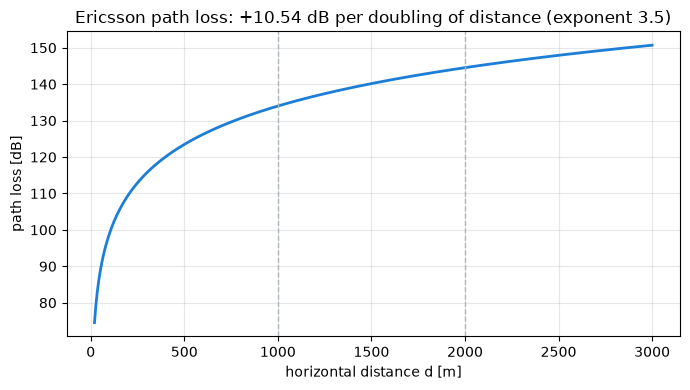

In [13]:
d = np.linspace(20, 3000, 400)
pl = np.array([path_loss_db(x) for x in d])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(d, pl, color="#1c7ed6", lw=2)
for d0 in (1000, 2000):
    ax.axvline(d0, ls="--", color="#adb5bd", lw=1)
ax.set_xlabel("horizontal distance d [m]")
ax.set_ylabel("path loss [dB]")
ax.set_title("Ericsson path loss: +10.54 dB per doubling of distance (exponent 3.5)")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


Path loss is monotone and steep — every doubling of distance costs about 10.5 dB, wherever that
doubling happens. It depends only on distance, not on tilt. Tilt enters through the **antenna
elevation gain**, the next piece, which decides how much of the transmitted power is aimed toward a
point at depression angle $\beta$.

## 3. Elevation gain and tilt — the antenna radiation pattern

Path loss depends only on distance; **tilt enters the model only here**, through the antenna's
elevation *radiation pattern* — how strongly the panel radiates toward each downward angle. Ericsson
approximates it as a parabola in dB, floored at the sidelobe level ([E] Eq. 4, the 3GPP TR 38.901
vertical pattern):

$$G_{\mathrm{el}}(\beta;\,t) = \max\!\left[\,-12\left(\frac{\beta - t}{\mathrm{HPBW}_{\mathrm{el}}}\right)^2,\ \mathrm{SLL}_{\mathrm{el}}\,\right],
\qquad \mathrm{HPBW}_{\mathrm{el}} = 6.5°,\quad \mathrm{SLL}_{\mathrm{el}} = -17\ \text{dB}.$$

Three things to hold onto:

- **It is a *relative* gain.** $G_{\mathrm{el}} = 0$ dB is the pattern's *peak* (a ratio of one to the
  peak), reached when the beam points straight at the point, $\beta = t$. It is not the absolute
  antenna gain — the peak gain $G_0 = 18$ dBi is added separately in the path-gain step (§4).
- **The $-12$ encodes the beamwidth.** The half-power beamwidth is the full angular width between the
  two directions where power falls to half ($-3$ dB); each is $\mathrm{HPBW}/2$ from the peak, and
  $-12\,(\pm\tfrac12)^2 = -3$, so the coefficient is exactly what makes the parabola hit $-3$ dB at
  the beam edge.
- **The floor bounds the attenuation.** Far off-beam the parabola would run to $-\infty$; the
  $\max(\cdot,\ \mathrm{SLL})$ clamps it at $-17$ dB — a coarse stand-in for off-beam radiation, not a
  model of individual sidelobes or nulls. Unclipped, the pattern is parabolic in dB, i.e. Gaussian in
  linear power.

`elevation_gain_db(elevation_deg, tilt_deg)` is exactly this expression. Below we verify its defining
points, then draw the pattern as a polar lobe.

In [15]:
from telecomopt.rf import elevation_gain_db

tilt = 8.0   # electrical downtilt [deg], positive downward

# defining points of the pattern, all relative to the 0 dB peak:
assert np.isclose(elevation_gain_db(tilt, tilt), 0.0)             # peak: beam points straight at the point
assert np.isclose(elevation_gain_db(tilt + 45, tilt), p.sll_el)  # far off-beam: clamped to the floor

#   By the HPBW convention they sit +/- HPBW/2 around the pointing angle 
half_power_angles = [tilt - p.hpbw_el / 2, tilt + p.hpbw_el / 2]   

for a in half_power_angles:
    assert np.isclose(elevation_gain_db(a, tilt), -3.0, atol=1e-9)
print(f"peak at beta = {tilt:.1f} deg (0 dB);  "
      f"-3 dB at beta = {half_power_angles[0]:.2f} and {half_power_angles[1]:.2f} deg;  "
      f"floor = {p.sll_el:.0f} dB")

peak at beta = 8.0 deg (0 dB);  -3 dB at beta = 4.75 and 11.25 deg;  floor = -17 dB


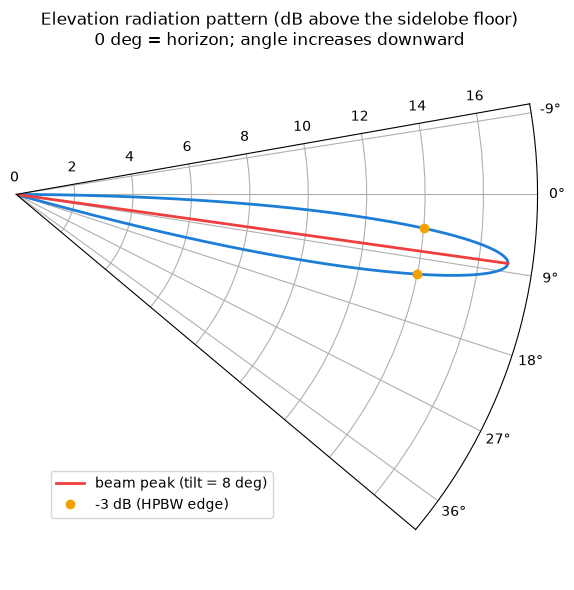

In [35]:
# The pattern drawn as a lobe: radius = how strongly the panel radiates toward each angle.
beta = np.linspace(-10, 40, 500)   # depression-angle sweep [deg]; positive = below horizon

#  the pattern gain toward each angle for this tilt.
#  elevation_gain_db(elevation_deg, tilt_deg) is scalar -> map it over beta (same pattern as before).
gain_db = np.array([elevation_gain_db(x,tilt) for x in beta]) 

# a polar radius must be >= 0, but gain_db runs from 0 (peak) down to SLL (floor).
# Shift the pattern up by the floor so SLL -> 0 and the peak -> -SLL (=17):  radius = gain - floor.
r = gain_db - p.sll_el         # hint: the floor is p.sll_el (a negative number, so subtracting it adds |SLL|)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="polar")
ax.set_theta_zero_location("E")    # 0 deg = horizon, radiating out from the tower
ax.set_theta_direction(-1)         # increasing angle sweeps downward (below the horizon)
ax.set_thetamin(-10); ax.set_thetamax(40)
ax.plot(np.radians(beta), r, color="#1c7ed6", lw=2)
ax.plot([np.radians(tilt)] * 2, [0, -p.sll_el], color="#f03e3e", lw=2,
        label=f"beam peak (tilt = {tilt:.0f} deg)")
for e in (tilt - p.hpbw_el / 2, tilt + p.hpbw_el / 2):
    ax.plot(np.radians(e), -3.0 - p.sll_el, "o", color="#f59f00")
ax.plot([], [], "o", color="#f59f00", label="-3 dB (HPBW edge)")
ax.set_title("Elevation radiation pattern (dB above the sidelobe floor)\n0 deg = horizon; angle increases downward")
ax.legend(loc="upper right", bbox_to_anchor=(.5, 0.22))
plt.tight_layout(); plt.show()

**Reading the lobe.** A single narrow main beam (HPBW $6.5°$) points at the tilt angle and falls
away fast; the orange markers are the $-3$ dB edges, the floor is the faint ring at radius 0. Steering
this lobe up or down (changing `tilt`) is the *only* thing tilt does — it slides which depression
angles, and therefore which ground distances, land in the strong part of the beam. Next (§4) we add
the peak gain $G_0$ and subtract path loss to get the **path gain** $G_0 + G_{\mathrm{el}} - PL$, then
transmit power and noise to reach SNR and spectral efficiency.